In [13]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score



In [6]:
# Generate noisy data
X, y = make_moons(n_samples=150, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


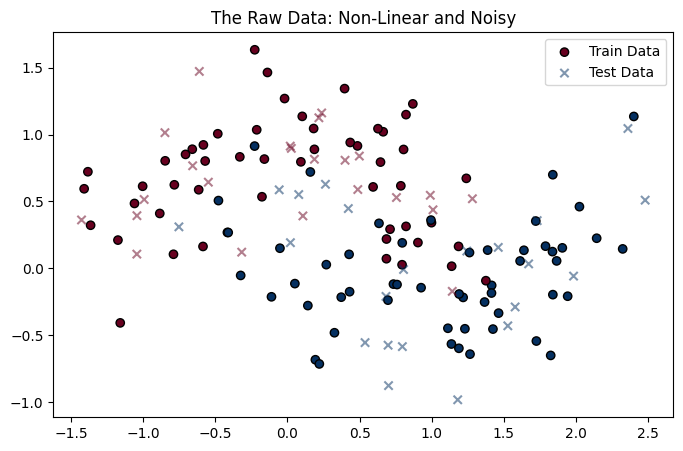

In [7]:
# Plot the raw data
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', label='Train Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha=0.5, label='Test Data')
plt.title("The Raw Data: Non-Linear and Noisy")
plt.legend()
plt.show()

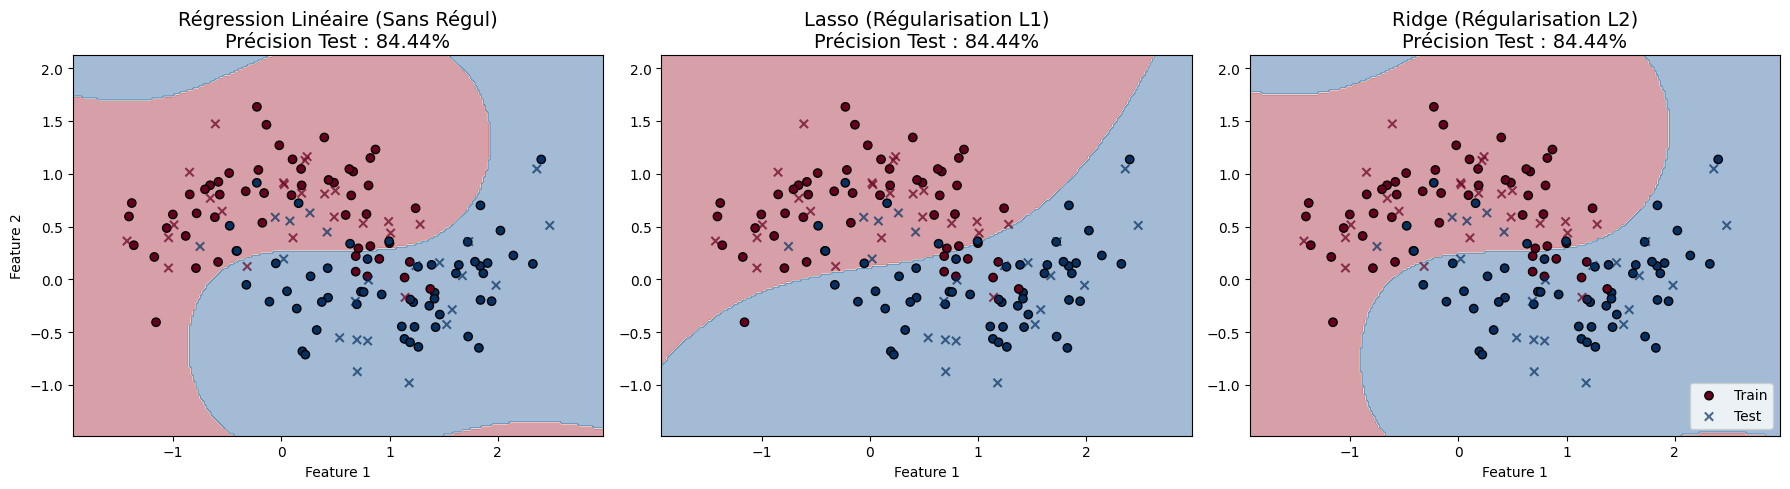

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import accuracy_score

# Préparation des features polynomiales (degré 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
scaler = StandardScaler()

# Définition des 3 modèles de Régression Linéaire
models_lin = {
    "Régression Linéaire (Sans Régul)": Pipeline([
        ("poly", poly),
        ("scaler", scaler),
        ("lin_reg", LinearRegression())
    ]),
    "Lasso (Régularisation L1)": Pipeline([
        ("poly", poly),
        ("scaler", scaler),
        # alpha contrôle la force de la régularisation L1
        ("lasso", Lasso(alpha=0.05, random_state=42)) 
    ]),
    "Ridge (Régularisation L2)": Pipeline([
        ("poly", poly),
        ("scaler", scaler),
        # alpha contrôle la force de la régularisation L2
        ("ridge", Ridge(alpha=1.0, random_state=42)) 
    ])
}

# Préparation de la figure et de la grille pour l'affichage
plt.figure(figsize=(18, 5))
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Boucle pour entraîner, prédire et afficher chaque modèle
for i, (name, model) in enumerate(models_lin.items()):
    # 1. Entraînement
    model.fit(X_train, y_train)
    
    # 2. Prédiction sur l'ensemble de test
    # La régression linéaire donne des valeurs continues (ex: -0.2, 0.8). 
    # On force la classification avec un seuil à 0.5.
    y_pred_continuous = model.predict(X_test)
    y_pred_class = (y_pred_continuous >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred_class)
    
    # 3. Affichage sur le graphique
    ax = plt.subplot(1, 3, i + 1)
    
    # Prédire sur toute la grille pour dessiner la frontière
    Z_continuous = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_class = (Z_continuous >= 0.5).astype(int)
    Z_class = Z_class.reshape(xx.shape)
    
    # Dessiner le fond (rouge/bleu)
    ax.contourf(xx, yy, Z_class, alpha=0.4, cmap='RdBu')
    
    # Dessiner les points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', label='Train')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha=0.7, label='Test')
    
    ax.set_title(f"{name}\nPrécision Test : {acc * 100:.2f}%", fontsize=14)
    ax.set_xlabel("Feature 1")
    if i == 0:
        ax.set_ylabel("Feature 2")

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Les trois modèles (régression linéaire, Lasso et Ridge) obtiennent la même précision de 84.44%, ce qui montre que la régularisation n’apporte pas d’amélioration dans ce cas. Les frontières de décision sont très similaires, indiquant que le problème est simple et bien séparé. Ainsi, un modèle linéaire suffit, tandis que Lasso simplifie légèrement le modèle et Ridge le rend plus stable, sans impact sur la performance.

C:\Users\MON_PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\MON_PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\MON

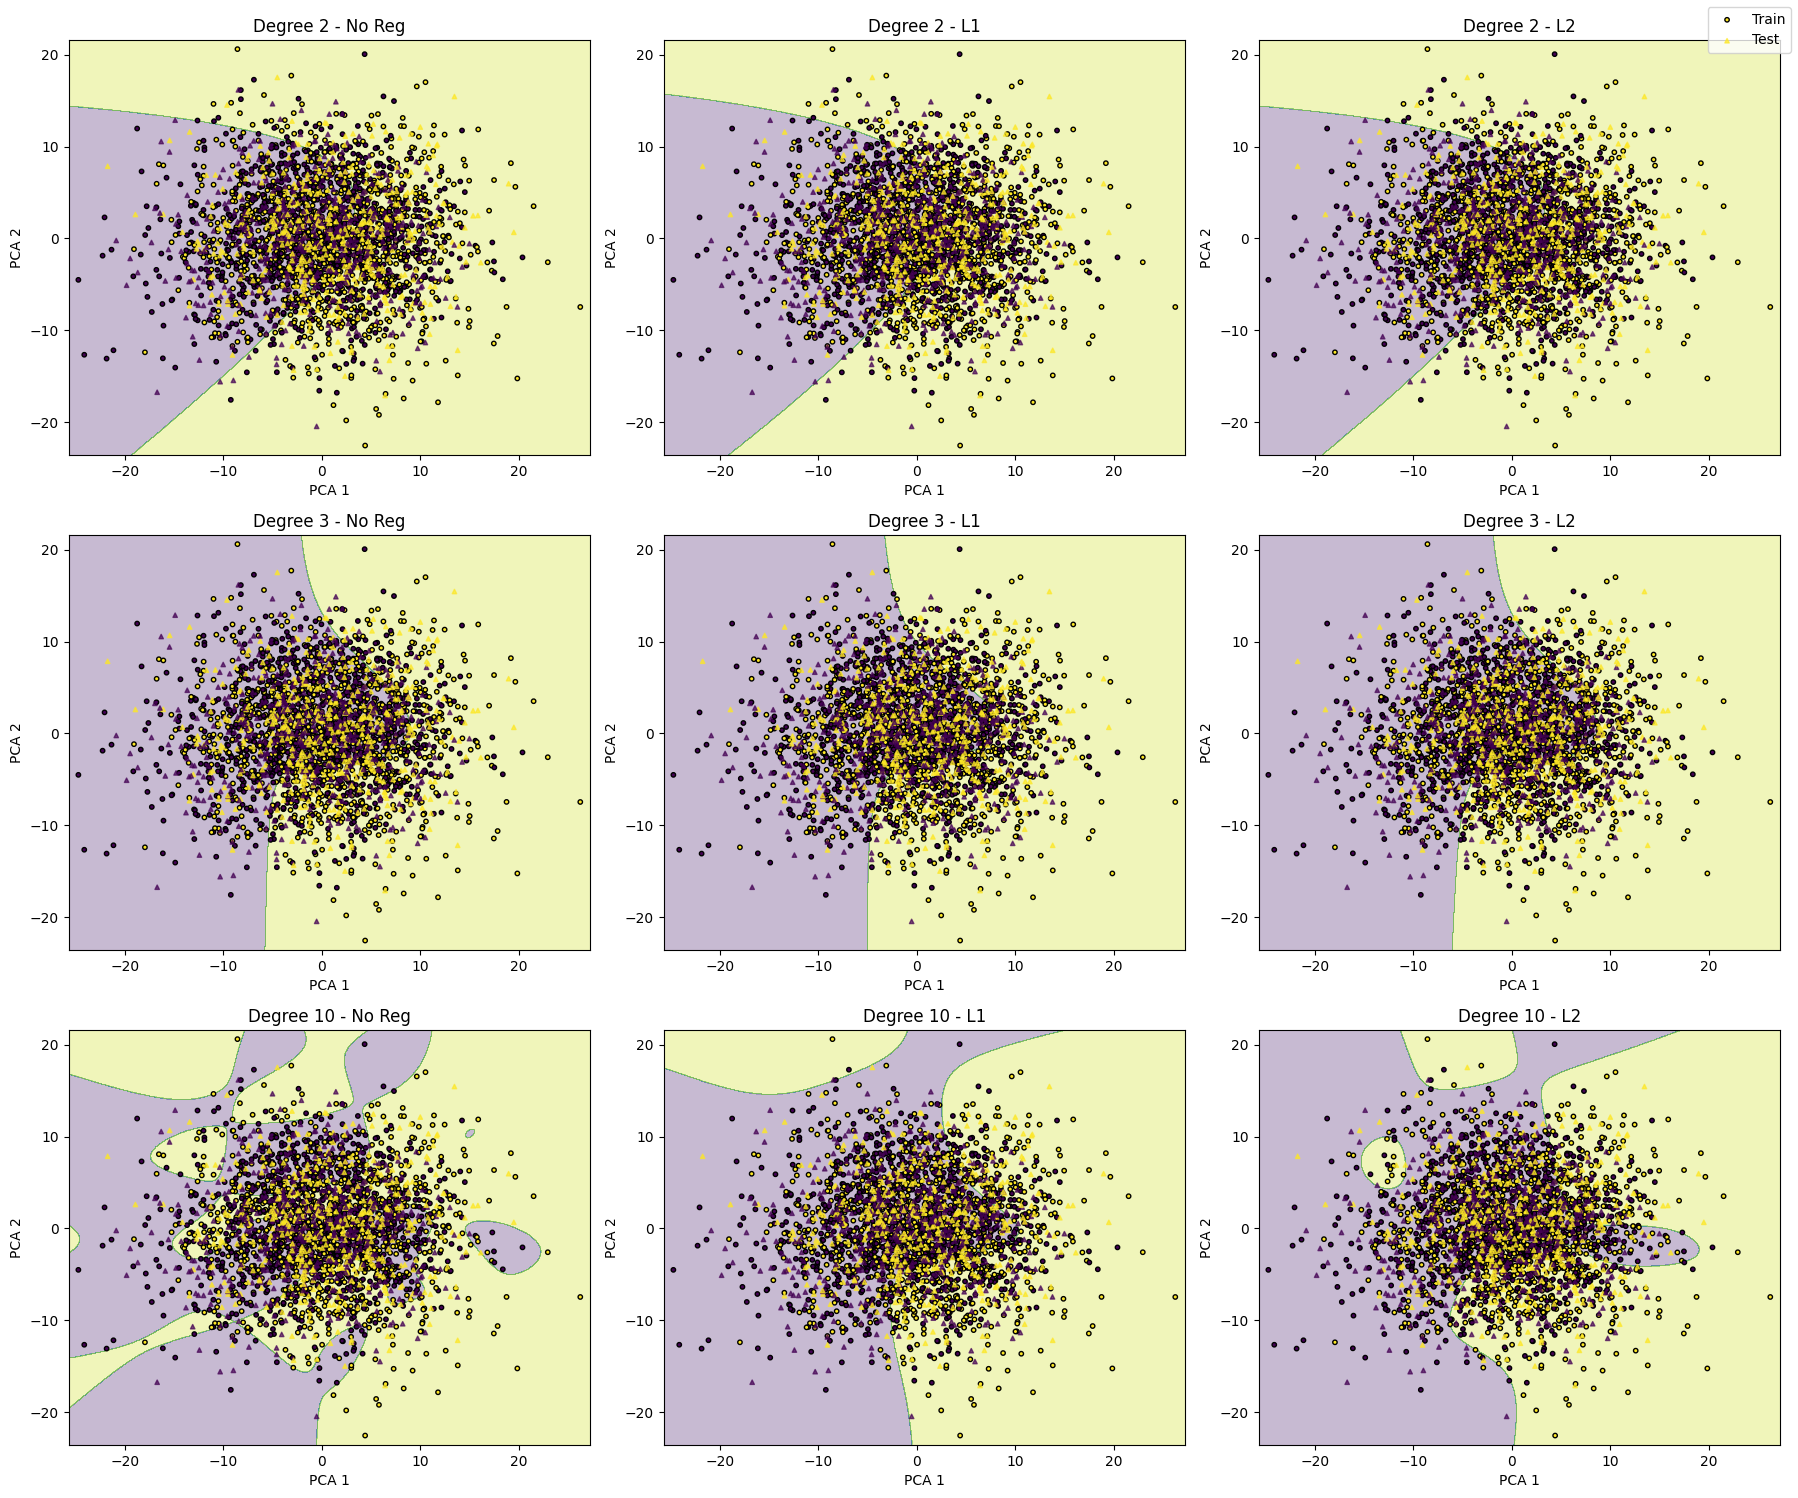

In [9]:
# 1) Generate dataset
X, y = make_classification(
    n_samples=3000,
    n_features=50,
    n_informative=10,
    n_redundant=10,
    n_classes=2,
    random_state=42
)

# 2) Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3) PCA → 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
X_pca = pca.transform(X)

# 4) Degrees
degrees = [2, 3, 10]

# 5) Model creator
def create_model(degree, reg_type):
    if reg_type == "none":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000))
        ])
    elif reg_type == "l1":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=5000))
        ])
    elif reg_type == "l2":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty='l2', solver='lbfgs', C=0.1, max_iter=5000))
        ])

# 6) Plot decision boundary
def plot_decision_boundary(model, ax, title):
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.05),
        np.arange(y_min, y_max, 0.05)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    # 🎨 couleurs changées ici
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

    ax.scatter(
        X_train_pca[:, 0], X_train_pca[:, 1],
        c=y_train, cmap='viridis', edgecolors='k',
        s=10, label='Train'
    )

    ax.scatter(
        X_test_pca[:, 0], X_test_pca[:, 1],
        c=y_test, cmap='viridis', marker='^',
        s=10, alpha=0.7, label='Test'
    )

    ax.set_title(title)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

# 7) Figure 3x3
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for i, degree in enumerate(degrees):
    model_none = create_model(degree, "none")
    model_none.fit(X_train_pca, y_train)
    plot_decision_boundary(model_none, axes[i, 0], f"Degree {degree} - No Reg")

    model_l1 = create_model(degree, "l1")
    model_l1.fit(X_train_pca, y_train)
    plot_decision_boundary(model_l1, axes[i, 1], f"Degree {degree} - L1")

    model_l2 = create_model(degree, "l2")
    model_l2.fit(X_train_pca, y_train)
    plot_decision_boundary(model_l2, axes[i, 2], f"Degree {degree} - L2")

# 8) Global legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

Les résultats montrent que pour degré 2 et 3, les frontières de décision sont relativement simples et similaires entre les trois modèles, ce qui indique une bonne généralisation sans surapprentissage. En revanche, pour degré 10, la frontière devient très complexe et irrégulière, surtout sans régularisation, ce qui montre un overfitting . L1 et L2 atténuent légèrement ce phénomène, mais la complexité reste élevée.

C:\Users\MON_PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\MON_PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\MON

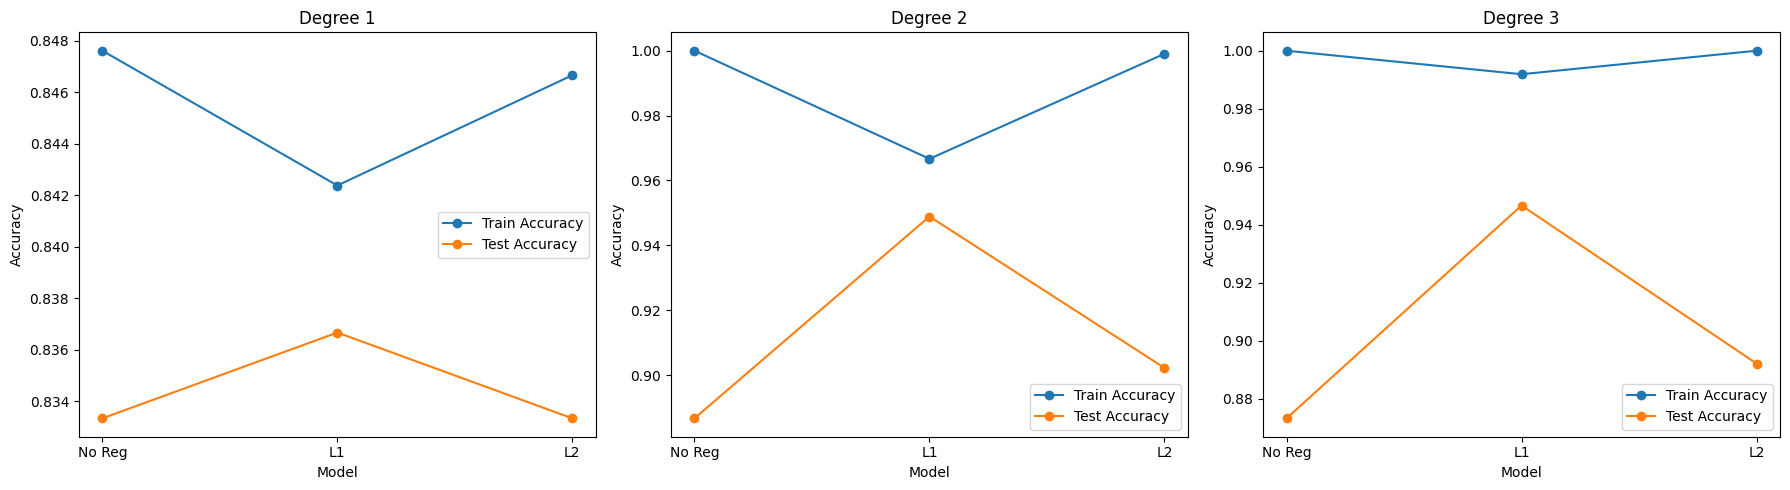

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1) Generate data
X, y = make_classification(
    n_samples=3000,
    n_features=50,
    n_informative=10,
    n_redundant=10,
    random_state=42
)

# 2) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3) Function to build models
def create_model(degree, reg_type):
    if reg_type == "none":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000))
        ])
    elif reg_type == "l1":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=5000))
        ])
    elif reg_type == "l2":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty='l2', solver='lbfgs', C=0.1, max_iter=5000))
        ])

# 4) Degrees
# Avoid extremely high-degree polynomial expansion on 50 features, which can exhaust memory.
degrees = [1, 2, 3]

# 5) Plot
fig, axes = plt.subplots(1, len(degrees), figsize=(6 * len(degrees), 5))

for i, degree in enumerate(degrees):

    train_acc = []
    test_acc = []
    labels = ['No Reg', 'L1', 'L2']
    regs = ['none', 'l1', 'l2']

    for reg in regs:
        model = create_model(degree, reg)
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Accuracy
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))

    # Plot for this degree
    ax = axes[i]
    x = np.arange(len(labels))

    ax.plot(x, train_acc, marker='o', label='Train Accuracy')
    ax.plot(x, test_acc, marker='o', label='Test Accuracy')

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(f"Degree {degree}")
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.tight_layout()
plt.show()

Plus le degré du polynôme augmente, plus le modèle a tendance à surapprendre.

La régularisation, surtout L1, aide à réduire le surapprentissage et à améliorer la performance sur le test